In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


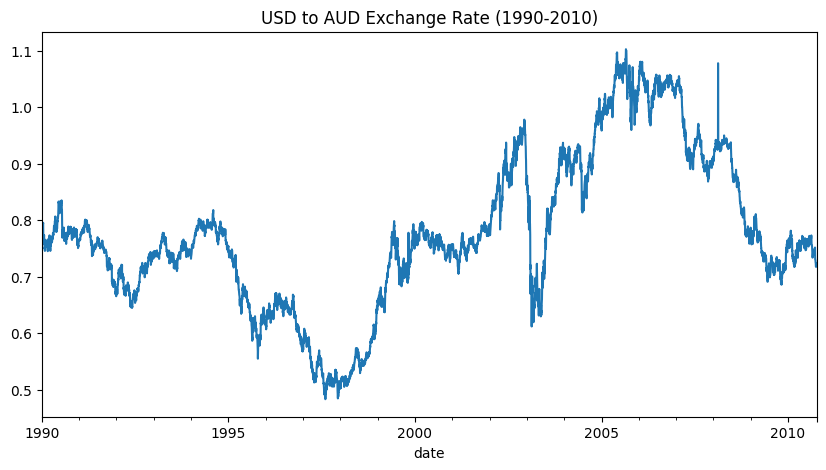

In [3]:
# Part 1: Data Preparation
df = pd.read_csv('exchange_rate.csv')
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)
series = df['Ex_rate']

# Visualization
series.plot(figsize=(10, 5), title='USD to AUD Exchange Rate (1990-2010)')
plt.show()

In [4]:
# Part 2: Model Building - ARIMA
# Splitting data (80% train, 20% test)
train_size = int(len(series) * 0.8)
train, test = series[0:train_size], series[train_size:len(series)]

# Fit ARIMA model (Parameters p,d,q selected based on ACF/PACF logic)
arima_model = ARIMA(train, order=(5,1,0))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [5]:
# Part 3: Model Building - Exponential Smoothing
# Using Holt's Linear Trend model as rates show a trend but no clear seasonality
exp_model = ExponentialSmoothing(train, trend='add', seasonal=None)
exp_fit = exp_model.fit()
exp_forecast = exp_fit.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA -> MAE: 0.1778, RMSE: 0.2055
Exponential Smoothing -> MAE: 0.2066, RMSE: 0.2391


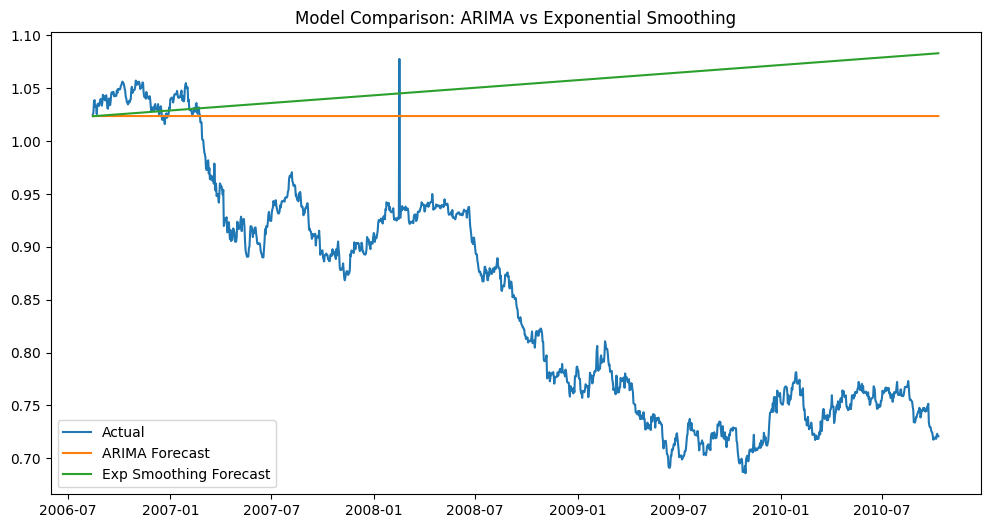

In [6]:
# Part 4: Evaluation
def evaluate(actual, pred, name):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"{name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

evaluate(test, arima_forecast, "ARIMA")
evaluate(test, exp_forecast, "Exponential Smoothing")

# Visualization of Forecasts
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, exp_forecast, label='Exp Smoothing Forecast')
plt.legend()
plt.title('Model Comparison: ARIMA vs Exponential Smoothing')
plt.show()